In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, precision_score, recall_score

In [11]:
# Problem 1
# Load dataset
file_path = "spambase.data"
df = pd.read_csv(file_path, header=None)

# First 57 columns = features, last column = label
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Function to evaluate a model
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    results = {
        "Training Error": 1 - train_accuracy,
        "Testing Error": 1 - test_accuracy,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Training F1": f1_score(y_train, y_train_pred),
        "Testing F1": f1_score(y_test, y_test_pred),
        "Training AUC": roc_auc_score(y_train, y_train_prob),
        "Testing AUC": roc_auc_score(y_test, y_test_prob)
    }

    return results

Dataset shape: (4601, 58)
Features shape: (4601, 57)
Labels shape: (4601,)
Training set shape: (3680, 57)
Testing set shape: (921, 57)


In [12]:
# Part 1
# Decision Tree using Information Gain 
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
tree_entropy.fit(X_train, y_train)

entropy_results = evaluate_model(tree_entropy, X_train, y_train, X_test, y_test)

print("\nDecision Tree with Information Gain")
for key, value in entropy_results.items():
    print(f"{key}: {value:.4f}")


Decision Tree with Information Gain
Training Error: 0.0003
Testing Error: 0.0803
Training Accuracy: 0.9997
Testing Accuracy: 0.9197
Training F1: 0.9997
Testing F1: 0.8984
Training AUC: 1.0000
Testing AUC: 0.9164


In [13]:
# Part 2 
# Decision Tree using Gini Index
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
tree_gini.fit(X_train, y_train)

gini_results = evaluate_model(tree_gini, X_train, y_train, X_test, y_test)

print("\nDecision Tree with Gini Index")
for key, value in gini_results.items():
    print(f"{key}: {value:.4f}")

# Comparison table
comparison_df = pd.DataFrame({
    "Entropy": entropy_results,
    "Gini": gini_results
})

print("\nComparison Table")
print(comparison_df)


Decision Tree with Gini Index
Training Error: 0.0003
Testing Error: 0.0890
Training Accuracy: 0.9997
Testing Accuracy: 0.9110
Training F1: 0.9997
Testing F1: 0.8877
Training AUC: 1.0000
Testing AUC: 0.9078

Comparison Table
                    Entropy      Gini
Training Error     0.000272  0.000272
Testing Error      0.080347  0.089034
Training Accuracy  0.999728  0.999728
Testing Accuracy   0.919653  0.910966
Training F1        0.999655  0.999655
Testing F1         0.898352  0.887671
Training AUC       1.000000  1.000000
Testing AUC        0.916363  0.907751



Pruning Results
Optimal depth: 11
Minimum testing error: 0.0695


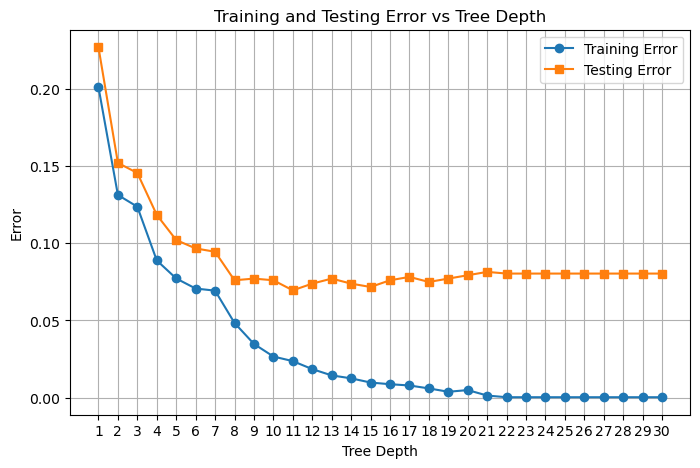


Depth vs Error Table
    Depth  Training Error  Testing Error
0       1        0.201087       0.226927
1       2        0.131250       0.152009
2       3        0.123641       0.145494
3       4        0.088859       0.118350
4       5        0.077174       0.102063
5       6        0.070652       0.096634
6       7        0.069293       0.094463
7       8        0.048370       0.076004
8       9        0.034783       0.077090
9      10        0.026630       0.076004
10     11        0.023641       0.069490
11     12        0.018478       0.073833
12     13        0.014402       0.077090
13     14        0.012500       0.073833
14     15        0.009783       0.071661
15     16        0.008696       0.076004
16     17        0.007880       0.078176
17     18        0.005978       0.074919
18     19        0.003804       0.077090
19     20        0.004891       0.079262
20     21        0.001359       0.081433
21     22        0.000272       0.080347
22     23        0.000272       0.0

In [14]:
# Part 3
# Pruning by limiting maximum depth
depths = range(1, 31)
train_errors = []
test_errors = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)

# Find optimal depth
optimal_depth = depths[np.argmin(test_errors)]
min_test_error = min(test_errors)

print("\nPruning Results")
print("Optimal depth:", optimal_depth)
print("Minimum testing error:", round(min_test_error, 4))

# Plot training and testing error vs depth
plt.figure(figsize=(8, 5))
plt.plot(depths, train_errors, marker='o', label='Training Error')
plt.plot(depths, test_errors, marker='s', label='Testing Error')

plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Training and Testing Error vs Tree Depth")
plt.xticks(list(depths))
plt.legend()
plt.grid(True)
plt.show()

# Print table of depth results
depth_table = pd.DataFrame({
    "Depth": list(depths),
    "Training Error": train_errors,
    "Testing Error": test_errors
})

print("\nDepth vs Error Table")
print(depth_table)

In [16]:
# Problem 2
# Helper function to evaluate a random forest model
def evaluate_rf(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Training Accuracy": accuracy_score(y_train, y_train_pred),
        "Testing Accuracy": accuracy_score(y_test, y_test_pred),
        "Training F1": f1_score(y_train, y_train_pred),
        "Testing F1": f1_score(y_test, y_test_pred),
        "Training AUC": roc_auc_score(y_train, y_train_prob),
        "Testing AUC": roc_auc_score(y_test, y_test_prob)
    }

    return results

In [17]:
# Part 1
tree_values = [10, 50, 100, 500]
rf_results = []

for T in tree_values:
    rf_model = RandomForestClassifier(
        n_estimators=T,
        random_state=42
    )
    rf_model.fit(X_train, y_train)

    results = evaluate_rf(rf_model, X_train, y_train, X_test, y_test)
    results["Number of Trees"] = T
    rf_results.append(results)

# Put results into a table
rf_results_df = pd.DataFrame(rf_results)
rf_results_df = rf_results_df[
    [
        "Number of Trees",
        "Training Accuracy", "Testing Accuracy",
        "Training F1", "Testing F1",
        "Training AUC", "Testing AUC"
    ]
]

print("Random Forest Results for Different Numbers of Trees")
print(rf_results_df)

Random Forest Results for Different Numbers of Trees
   Number of Trees  Training Accuracy  Testing Accuracy  Training F1  \
0               10           0.995380          0.942454     0.994112   
1               50           0.999728          0.942454     0.999655   
2              100           0.999728          0.945711     0.999655   
3              500           0.999728          0.944625     0.999655   

   Testing F1  Training AUC  Testing AUC  
0    0.925035      0.999947     0.979731  
1    0.925247      1.000000     0.982676  
2    0.929775      1.000000     0.983385  
3    0.928270      1.000000     0.983575  


In [28]:
# Part 2 
# Use existing models
dt_entropy_results = evaluate_model(tree_entropy)
dt_gini_results = evaluate_model(tree_gini)

dt_df = pd.DataFrame([
    {
        "Model": "Decision Tree (Entropy)",
        "Testing Accuracy": dt_entropy_results["Testing Accuracy"],
        "Testing F1": dt_entropy_results["Testing F1"],
        "Testing AUC": dt_entropy_results["Testing AUC"]
    },
    {
        "Model": "Decision Tree (Gini)",
        "Testing Accuracy": dt_gini_results["Testing Accuracy"],
        "Testing F1": dt_gini_results["Testing F1"],
        "Testing AUC": dt_gini_results["Testing AUC"]
    }
])

# Random Forest results 
rf_compare_df = rf_results_df[[
    "Number of Trees",
    "Testing Accuracy",
    "Testing F1",
    "Testing AUC"
]].copy()

rf_compare_df["Model"] = rf_compare_df["Number of Trees"].apply(
    lambda x: f"Random Forest ({x} trees)"
)

rf_compare_df = rf_compare_df[[
    "Model",
    "Testing Accuracy",
    "Testing F1",
    "Testing AUC"
]]

# Combine
comparison_df = pd.concat([dt_df, rf_compare_df], ignore_index=True)

print(comparison_df)

                       Model  Testing Accuracy  Testing F1  Testing AUC
0    Decision Tree (Entropy)          0.919653    0.898352     0.916363
1       Decision Tree (Gini)          0.910966    0.887671     0.907751
2   Random Forest (10 trees)          0.942454    0.925035     0.979731
3   Random Forest (50 trees)          0.942454    0.925247     0.982676
4  Random Forest (100 trees)          0.945711    0.929775     0.983385
5  Random Forest (500 trees)          0.944625    0.928270     0.983575


Top 10 Most Important Features
    Feature  Importance
51       52    0.112541
52       53    0.099743
6         7    0.079959
54       55    0.062084
15       16    0.061876
55       56    0.056778
20       21    0.055698
56       57    0.048756
24       25    0.047359
23       24    0.035014


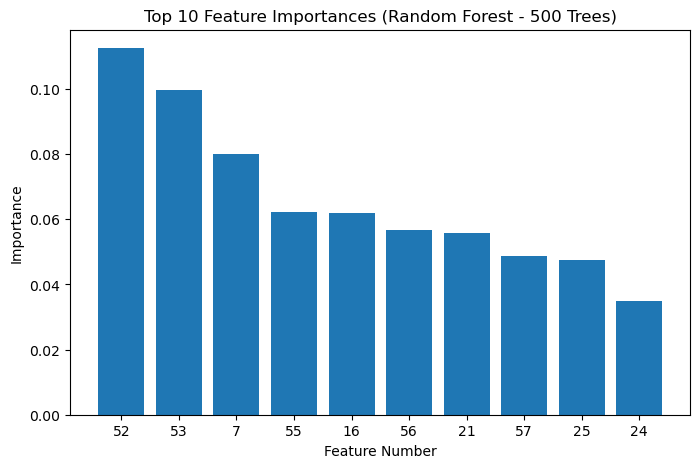

In [29]:
# Part 3
# Train Random Forest with 500 trees 
rf_500 = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)
rf_500.fit(X_train, y_train)

# Get feature importance
importances = rf_500.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": range(1, len(importances) + 1),
    "Importance": importances
})

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Print top 10 features
print("Top 10 Most Important Features")
print(importance_df.head(10))

# Plot 
top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.bar(top10["Feature"].astype(str), top10["Importance"])

plt.xlabel("Feature Number")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest - 500 Trees)")

plt.show()

In [32]:
# Problem 3
# Part 1
def evaluate_model(model):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Training Accuracy": accuracy_score(y_train, y_train_pred),
        "Testing Accuracy": accuracy_score(y_test, y_test_pred),
        "Training F1": f1_score(y_train, y_train_pred),
        "Testing F1": f1_score(y_test, y_test_pred),
        "Training AUC": roc_auc_score(y_train, y_train_prob),
        "Testing AUC": roc_auc_score(y_test, y_test_prob)
    }

# Train AdaBoost with different numbers of base classifiers
tree_values = [10, 50, 100, 500]
results = []

for T in tree_values:
    ada_model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T,
        algorithm="SAMME",
        random_state=42
    )
    
    ada_model.fit(X_train, y_train)
    metrics = evaluate_model(ada_model)
    
    metrics["Number of Trees"] = T
    results.append(metrics)

# Convert to DataFrame
ada_results_df = pd.DataFrame(results)

# Order columns
ada_results_df = ada_results_df[
    [
        "Number of Trees",
        "Training Accuracy",
        "Testing Accuracy",
        "Training F1",
        "Testing F1",
        "Training AUC",
        "Testing AUC"
    ]
]

print("AdaBoost Results")
print(ada_results_df)

AdaBoost Results
   Number of Trees  Training Accuracy  Testing Accuracy  Training F1  \
0               10           0.904620          0.891422     0.879091   
1               50           0.934239          0.918567     0.914548   
2              100           0.943207          0.927253     0.926331   
3              500           0.956522          0.932682     0.944251   

   Testing F1  Training AUC  Testing AUC  
0    0.862259      0.964118     0.954180  
1    0.894811      0.981685     0.973644  
2    0.905767      0.985718     0.977838  
3    0.913649      0.990490     0.980669  


In [33]:
# Part 2
def evaluate_model(model):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Training Accuracy": accuracy_score(y_train, y_train_pred),
        "Testing Accuracy": accuracy_score(y_test, y_test_pred),
        "Training F1": f1_score(y_train, y_train_pred),
        "Testing F1": f1_score(y_test, y_test_pred),
        "Training AUC": roc_auc_score(y_train, y_train_prob),
        "Testing AUC": roc_auc_score(y_test, y_test_prob)
    }

# Compare AdaBoost and Random Forest for different numbers of base learners
tree_values = [10, 50, 100, 500]
results = []

for T in tree_values:
    # Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=T,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    rf_results = evaluate_model(rf_model)

    # AdaBoost model
    ada_model = AdaBoostClassifier(
        n_estimators=T,
        algorithm="SAMME",
        random_state=42
    )
    ada_model.fit(X_train, y_train)
    ada_results = evaluate_model(ada_model)

    # Save Random Forest results
    results.append({
        "Model": f"Random Forest ({T} trees)",
        **rf_results
    })

    # Save AdaBoost results
    results.append({
        "Model": f"AdaBoost ({T} trees)",
        **ada_results
    })

# Putting results into a DataFrame
comparison_df = pd.DataFrame(results)

print("AdaBoost vs Random Forest Comparison")
print(comparison_df)

AdaBoost vs Random Forest Comparison
                       Model  Training Accuracy  Testing Accuracy  \
0   Random Forest (10 trees)           0.995380          0.942454   
1        AdaBoost (10 trees)           0.904620          0.891422   
2   Random Forest (50 trees)           0.999728          0.942454   
3        AdaBoost (50 trees)           0.934239          0.918567   
4  Random Forest (100 trees)           0.999728          0.945711   
5       AdaBoost (100 trees)           0.943207          0.927253   
6  Random Forest (500 trees)           0.999728          0.944625   
7       AdaBoost (500 trees)           0.956522          0.932682   

   Training F1  Testing F1  Training AUC  Testing AUC  
0     0.994112    0.925035      0.999947     0.979731  
1     0.879091    0.862259      0.964118     0.954180  
2     0.999655    0.925247      1.000000     0.982676  
3     0.914548    0.894811      0.981685     0.973644  
4     0.999655    0.929775      1.000000     0.983385  
5    

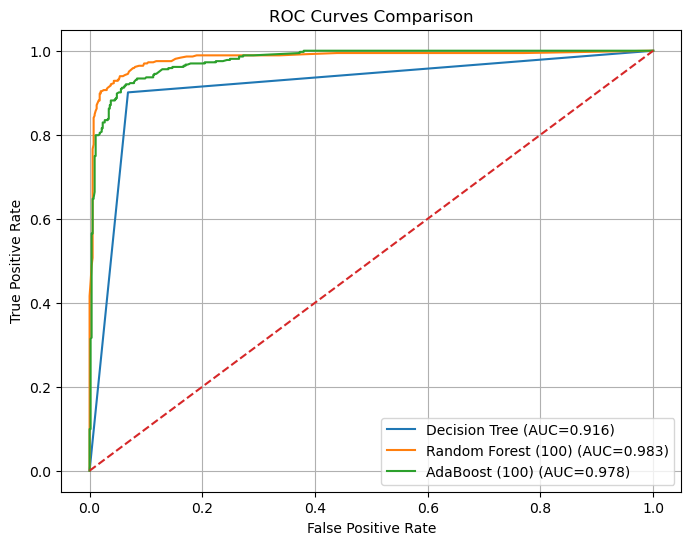

In [26]:
# Part 3
# Training models
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

ada = AdaBoostClassifier(n_estimators=100, algorithm="SAMME", random_state=42)
ada.fit(X_train, y_train)

# Probabilities
dt_prob = dt.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
ada_prob = ada.predict_proba(X_test)[:, 1]

# Compute ROC
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
ada_auc = auc(ada_fpr, ada_tpr)

# Plotting
plt.figure(figsize=(8,6))

plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC={dt_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (100) (AUC={rf_auc:.3f})")
plt.plot(ada_fpr, ada_tpr, label=f"AdaBoost (100) (AUC={ada_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [58]:
# Problem 4
# Part 1
# Load dataset
df = pd.read_csv("agaricus-lepiota.data", header=None)

y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Naive Bayes Class
class NaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.class_probs = {}
        self.feature_probs = {}

        for c in self.classes:
            X_c = X[y == c]
            self.class_probs[c] = len(X_c) / len(X)

            self.feature_probs[c] = []
            for col in range(X.shape[1]):
                values, counts = np.unique(X_c[:, col], return_counts=True)
                probs = {}

                total = len(X_c)
                k = len(np.unique(X[:, col])) 

                for v, count in zip(values, counts):
                    probs[v] = (count + 1) / (total + k)  

                self.feature_probs[c].append(probs)
# Part 2    
    def predict(self, X):
        predictions = []

        for x in X:
            class_scores = {}

            for c in self.classes:
                log_prob = np.log(self.class_probs[c])

                for i, val in enumerate(x):
                    probs = self.feature_probs[c][i]

                    if val in probs:
                        log_prob += np.log(probs[val])
                    else:
                        log_prob += np.log(1e-6)

                class_scores[c] = log_prob

            predictions.append(max(class_scores, key=class_scores.get))

        return np.array(predictions)

In [59]:
# Part 3
# Train model
nb = NaiveBayes()
nb.fit(X_train, y_train)

# Predict
y_pred = nb.predict(X_test)

# Metrics
print("MY NAIVE BAYES")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="e"))
print("Recall:", recall_score(y_test, y_pred, pos_label="e"))
print("F1 Score:", f1_score(y_test, y_pred, pos_label="e"))

MY NAIVE BAYES
Accuracy: 0.9916297390448056
Precision: 0.9923002887391723
Recall: 0.9913461538461539
F1 Score: 0.9918229918229918


In [55]:
# Part 4
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB

encoder = OneHotEncoder(handle_unknown='ignore')
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

# Train sklearn Naive Bayes
nb_sklearn = MultinomialNB()
nb_sklearn.fit(X_train_enc, y_train)

# Predict
y_pred_sklearn = nb_sklearn.predict(X_test_enc)

# Metrics
print("SKLEARN RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))
print("Precision:", precision_score(y_test, y_pred_sklearn, pos_label="e"))
print("Recall:", recall_score(y_test, y_pred_sklearn, pos_label="e"))
print("F1 Score:", f1_score(y_test, y_pred_sklearn, pos_label="e"))

SKLEARN RESULTS
Accuracy: 0.9487936976858691
Precision: 0.9156305506216696
Recall: 0.9913461538461539
F1 Score: 0.9519852262234534
